In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import joblib
from numpy import genfromtxt
import os
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
# ── list every (latent_dim, beta, directory, label) saved in 'results'
CONFIGS = [
    (5,   0.0005, 'results/ld05_b0.0005',  'd=5'),
    (10,  0.0005, 'results/ld10_b0.0005',  'd=10'),
    (15,  0.0005, 'results/ld15_b0.0005',  'd=15'),
    (20,  0.0005, 'results/ld20_b0.0005',  'd=20* (Selected Configuration)'),
    (25,  0.0005, 'results/ld25_b0.0005',  'd=25'),
    (30,  0.0005, 'results/ld30_b0.0005',  'd=30'),
    # beta sensitivity 0.0001
    (5,  0.0001, 'results/ld05_b0.0001',  'd=5'),#, beta=1e-4'),
    (10, 0.0001, 'results/ld10_b0.0001',  'd=10'),#, beta=1e-4'),
    (15, 0.0001, 'results/ld15_b0.0001',  'd=15'),#, beta=1e-4'),
    (20, 0.0001, 'results/ld20_b0.0001',  'd=20'),#, beta=1e-4'),
    (25, 0.0001, 'results/ld25_b0.0001',  'd=25'),#, beta=1e-4'),
    (30, 0.0001, 'results/ld30_b0.0001',  'd=30'),#, beta=1e-4'),
    # beta sensitivity 0.005
    #(5,  0.005, 'results/ld05_b0.005',  'd=5'),#, beta=1e-3'),
    #(10, 0.005, 'results/ld10_b0.005',  'd=10'),#, beta=1e-3'),
    #(20,  0.005, 'results/ld20_b0.005',  'd=20'),#, beta=1e-3'),
    #(30,  0.005, 'results/ld30_b0.005',  'd=30'),#, beta=1e-3')
]

In [3]:
def compute_evr_variance(results_dir):
    ds  = xr.open_dataset(os.path.join(results_dir, 'latent_representations_zmean.nc'))
    z   = ds['z_mean'].values
    z_c = z - z.mean(axis=0)
    evr = np.var(z_c, axis=0)
    evr = evr / evr.sum()
    return float(np.var(evr))

In [4]:
def compute_traversal_var(results_dir):
    files = {
        'sst': os.path.join(results_dir, 'slope_maps_sst.npy'),
        'ohc': os.path.join(results_dir, 'slope_maps_ohc.npy'),
        'olr': os.path.join(results_dir, 'slope_maps_olr.npy'),
    }
    loaded = {k: np.load(v) for k, v in files.items() if os.path.exists(v)}
    if not loaded:
        raise FileNotFoundError(f'No slope_maps_*.npy in {results_dir}')
    n_ld  = next(iter(loaded.values())).shape[0]
    per_ld = np.array([
        np.mean([np.nanvar(arr[ld] / np.nanstd(arr)) for arr in loaded.values()])
        for ld in range(n_ld)
    ])

    return float(np.var(per_ld))


records = []
for (n_ld, beta, rdir, label) in CONFIGS:
    if not os.path.isdir(rdir):
        print(f'  [skip] {rdir} not found')
        continue
    x = compute_evr_variance(rdir)
    y = compute_traversal_var(rdir)
    records.append(dict(n_ld=n_ld, beta=beta, label=label, x=x, y=y))
    print(f'  {label:20s}  Var(EVR)={x:.6f}  Var(spat_var)={y:.4e}')

  d=5                   Var(EVR)=0.002070  Var(spat_var)=5.3706e-02
  d=10                  Var(EVR)=0.000999  Var(spat_var)=7.0135e-02
  d=15                  Var(EVR)=0.000314  Var(spat_var)=4.5929e-02
  d=20* (Selected Configuration)  Var(EVR)=0.000193  Var(spat_var)=6.1668e-02
  d=25                  Var(EVR)=0.000069  Var(spat_var)=4.1186e-02
  d=30                  Var(EVR)=0.000077  Var(spat_var)=4.7388e-02
  d=5                   Var(EVR)=0.001761  Var(spat_var)=9.3222e-02
  d=10                  Var(EVR)=0.001117  Var(spat_var)=8.2803e-02
  d=15                  Var(EVR)=0.000406  Var(spat_var)=3.5556e-02
  d=20                  Var(EVR)=0.000308  Var(spat_var)=3.4991e-02
  d=25                  Var(EVR)=0.000151  Var(spat_var)=4.3272e-02
  d=30                  Var(EVR)=0.000112  Var(spat_var)=4.7789e-02


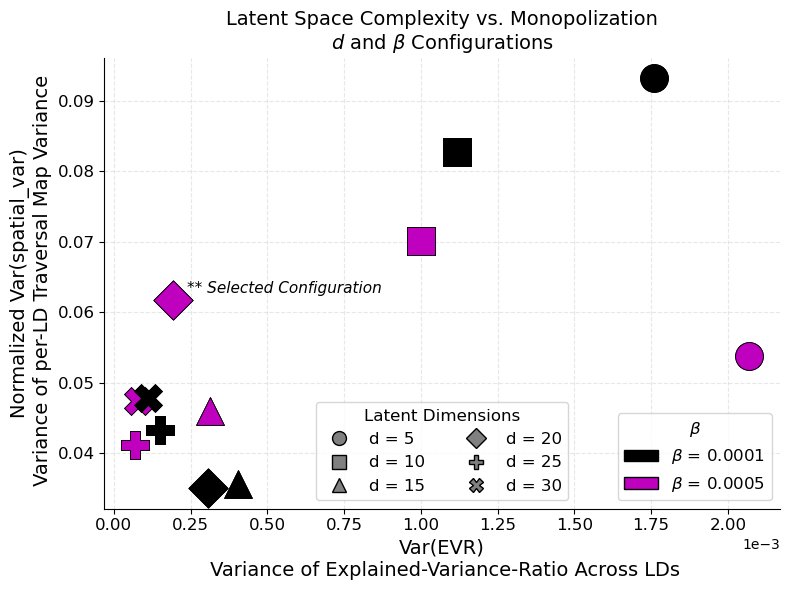

In [6]:
# plotting
fig, ax = plt.subplots(figsize=(8, 6))

betas = sorted(set(r['beta'] for r in records))
n_lds = sorted(set(r['n_ld'] for r in records))

beta_color = {
    0.0001: 'black',
    0.0005: 'm',
}

ld_marker = {
    5:  'o',
    10: 's',
    15: '^',
    20: 'D',
    25: 'P',
    30: 'X',
}

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for r in records:
    ax.scatter(
        r['x'], r['y'], s=400,
        color=beta_color[r['beta']],
        marker=ld_marker[r['n_ld']],
        edgecolors='k', linewidths=0.6, zorder=3
    )

ax.set_xlabel('Var(EVR)\n Variance of Explained-Variance-Ratio Across LDs', fontsize=14)
ax.set_ylabel('Normalized Var(spatial_var)\n Variance of per-LD Traversal Map Variance', fontsize=14)
ax.set_title(
    'Latent Space Complexity vs. Monopolization\n$d$ and $\\beta$ Configurations',
    fontsize=14
)
ax.tick_params(axis='both', labelsize=12)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
ax.grid(True, alpha=0.3, linestyle='--')

# beta legend (color)
leg1 = ax.legend(
    handles=[Patch(facecolor=beta_color[b], edgecolor='k', label=f'$\\beta$ = {b}') for b in betas],
    title='$\\beta$', loc='lower right', fontsize=12, title_fontsize=12
)
ax.add_artist(leg1)

# d legend (marker shape)
leg2 = ax.legend(
    handles=[Line2D([0], [0], marker=ld_marker[n], color='w', markerfacecolor='grey',
                    markeredgecolor='k', markersize=10, label=f'd = {n}') for n in n_lds],
    title='Latent Dimensions', loc='lower center', ncol=2, fontsize=12, title_fontsize=12
)

for r in records:
    ax.scatter(
        r['x'], r['y'], s=400,
        color=beta_color[r['beta']],
        marker=ld_marker[r['n_ld']],
        edgecolors='k', linewidths=0.6, zorder=3
    )
    if r['n_ld'] == 20 and r['beta'] == 0.0005:
        ax.annotate(
            '** Selected Configuration', (r['x'], r['y']),
            textcoords='offset points', xytext=(10, 5),
            fontsize=11, fontstyle='italic'
            #arrowprops=dict(arrowstyle='->', color='black', lw=1.2)
        )

plt.tight_layout()
#plt.savefig('latent_complexity_tradeoff_0618.png', bbox_inches='tight')
plt.show()